### py311_env - Python environment

In [1]:
!pip install -q deepeval

In [2]:
# load environment variable from .env file
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from deepeval import evaluate
from deepeval.test_case import LLMTestCase, LLMTestCaseParams, Turn, TurnParams, ConversationalTestCase

import pandas as pd
from deepeval.dataset import Golden

from deepeval.dataset import EvaluationDataset, Golden
from deepeval.metrics import AnswerRelevancyMetric, ConversationalGEval, ConversationCompletenessMetric, BiasMetric
from deepeval import evaluate


In [4]:
convo_geval_focus = ConversationalGEval(name="Focus", criteria = "Does the response directly address the specific question or task?")
convo_geval_helpful = ConversationalGEval(name="Helpful", criteria = "Does the response meaningfully help the user?")
convo_geval_completeness = ConversationalGEval(name="Completeness", criteria = "Does the response fully address the question without major omissions?")
convo_geval_voice = ConversationalGEval(name="Voice", criteria = "Does the response use clear, active voice?")
convo_geval_engagement = ConversationalGEval(name="Engagement", criteria = "Does the response use appropriate and engaging language?")

convo_completeness = ConversationCompletenessMetric()

In [5]:
import pandas as pd
data = pd.read_csv("data_bank/simple.csv")
data_sel = data.dropna(subset=['tursio_response']).reset_index(drop=True)   
data_sel.head()

,persona,kpi,difficulty,synthetic_questions,tursio_response
0,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What percentage of accounts have made no trans...,Key Insight:\nAll accounts in the dataset (100...
1,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What is the total number of accounts that have...,Key Insights:\n\nThe query indicates that 0 di...
2,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What percentage of accounts have a loan balanc...,Key Insight:\n\n68.8% of the accounts in the d...
3,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,How many accounts have a credit card linked th...,Key Insight:\n\nThere are exactly 214 accounts...
4,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What is the total number of accounts that have...,Key Insight:\n\nThe dataset indicates that 0 u...


In [6]:
turns = []
for idx, row in data_sel.iterrows():
    turn_user = Turn(role="user", retrieval_context=[f"user persona: {row['persona']}", f"KPI : {row['kpi']}"]  ,content=row["synthetic_questions"])   
    turn_assistant = Turn(role="assistant", content=row["tursio_response"])
    convo_test_case = ConversationalTestCase(turns=[turn_user, turn_assistant])

    turns.append(convo_test_case)

print (f"Added test cases for {len(turns)}")

Added test cases for 60


In [7]:
turns[0]

ConversationalTestCase(turns=[Turn(role='user', content='What percentage of accounts have made no transactions in the last 90 days?', retrieval_context=['user persona: Product Manager; Member Analytics Lead', 'KPI : Early Closure Rate; Account Churn (‚â§90 days)']), Turn(role='assistant', content='Key Insight:\nAll accounts in the dataset (100%) have made no transactions in the last 90 days.')], scenario=None, context=None, name=None, user_description=None, expected_outcome=None, chatbot_role=None, additional_metadata=None, comments=None, tags=None, mcp_servers=None, multimodal=False)

In [8]:
import time
import os
from deepeval.evaluate import AsyncConfig

import sys
from io import StringIO
import contextlib


# Increase timeout for API calls
os.environ["DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE"] = "600"
os.environ["DEEPEVAL_VERBOSE"] = "false"

# Configure async evaluation with delays to avoid rate limits
async_config = AsyncConfig(
    run_async=False,  # Run synchronously to add delays
)

all_results = []
batch_size = 2  # Reduced from 5 to 2 test cases per batch

for step in range(0, len(turns), batch_size):
    # Evaluate with delay between API calls
    print(f"Evaluating test cases {step} to {min(step + batch_size, len(convo_test_case.turns))}")
    
    test_batch = turns[step:step + batch_size]
    
    try:
        with contextlib.redirect_stdout(StringIO()), contextlib.redirect_stderr(StringIO()):

            results = evaluate(
                test_cases=test_batch,
                metrics=[convo_geval_focus
                        , convo_geval_completeness
                        , convo_geval_engagement
                        , convo_geval_helpful
                        , convo_geval_voice
                        , convo_completeness],
                async_config=async_config,
            )
        for res in results.test_results:
            all_results.append(res)
    except Exception as e:
        print(f"Error evaluating batch at {step}: {e}")
        continue

    # Add delay to avoid rate limiting
    time.sleep(3)

print(f"Evaluated {len(all_results)} test cases")


✨ You're running DeepEval's latest Focus [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Completeness [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Engagement [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Helpful [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Voice [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

...

Output()

Evaluating test cases 58 to 2


⚠ WARNING: No hyperparameters logged.
» ]8;id=153493;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 19.31s | token cost: 0.021934 USD)
» Test Results (2 total tests):
   » Pass Rate: 100.0% | Passed: 2 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

Evaluated 60 test cases


In [9]:
all_results[0].metrics_data

[MetricData(name='Focus [Conversational GEval]', threshold=0.5, success=True, score=1.0, reason="The assistant directly answers the user's question by stating that 100% of accounts have made no transactions in the last 90 days. The roles are correctly aligned, with the user asking a question and the assistant providing a clear, relevant response. All evaluation steps are fully met.", strict_mode=False, evaluation_model='gpt-4.1', error=None, evaluation_cost=0.002634, verbose_logs='Criteria:\nDoes the response directly address the specific question or task? \n \nEvaluation Steps:\n[\n    "For each turn, identify the Role (user or assistant) and determine the expected action based on the Role.",\n    "Examine the Content of each assistant response to check if it directly addresses the specific question or task posed by the user in the preceding turn.",\n    "Assess whether the Content and Role are aligned (e.g., the assistant provides answers, the user asks questions or gives tasks).",\n

In [ ]:
# test_result.turns

NameError: name 'test_result' is not defined

In [11]:
import pandas as pd

data_for_df = []

for test_result in all_results: #results.test_results:
    for m in test_result.metrics_data:
        row = {
            'name': test_result.name,
            'input': test_result.input,
            'actual_output': test_result.actual_output,
            'expected_output': test_result.expected_output,
            'turns': test_result.turns,
            'test_success': test_result.success
        }

    # if test_result.metrics_data:
     
        # Assuming one metric per test case for simplicity based on previous output
        metric_data = m #test_result.metrics_data[0]
        row['metric_name'] = metric_data.name
        row['metric_score'] = metric_data.score
        row['metric_threshold'] = metric_data.threshold
        row['metric_success'] = metric_data.success
        row['metric_reason'] = metric_data.reason
    # else:
    #     row['metric_name'] = None
    #     row['metric_score'] = None
    #     row['metric_threshold'] = None
    #     row['metric_success'] = None
    #     row['metric_reason'] = None

        data_for_df.append(row)

df_results = pd.DataFrame(data_for_df)
display(df_results.head())

,name,input,actual_output,expected_output,turns,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason
0,conversational_test_case_0,None,None,None,[role='user' content='What percentage of accou...,True,Focus [Conversational GEval],1.000000,0.5,True,The assistant directly answers the user's ques...
1,conversational_test_case_0,None,None,None,[role='user' content='What percentage of accou...,True,Completeness [Conversational GEval],1.000000,0.5,True,The assistant correctly identifies its role an...
2,conversational_test_case_0,None,None,None,[role='user' content='What percentage of accou...,True,Engagement [Conversational GEval],0.898201,0.5,True,The user is clear and relevant in their questi...
3,conversational_test_case_0,None,None,None,[role='user' content='What percentage of accou...,True,Helpful [Conversational GEval],1.000000,0.5,True,The assistant directly and clearly answers the...
4,conversational_test_case_0,None,None,None,[role='user' content='What percentage of accou...,True,Voice [Conversational GEval],1.000000,0.5,True,"Both the user and assistant use clear, direct ..."


In [12]:
df_results.shape

(360, 11)

In [13]:
df_results.to_csv("deepeval_tursio_results_simple_convo.csv", index=False)

In [ ]:
df_results.metric_name.unique()

array(['Focus [Conversational GEval]',
       'Completeness [Conversational GEval]',
       'Engagement [Conversational GEval]',
       'Helpful [Conversational GEval]', 'Voice [Conversational GEval]',
       'Conversation Completeness'], dtype=object)

In [ ]:
df_results[df_results['metric_success'] == False].groupby(["metric_name"])["name"].count()

metric_name
Completeness [Conversational GEval]    4
Conversation Completeness              6
Engagement [Conversational GEval]      3
Focus [Conversational GEval]           4
Helpful [Conversational GEval]         3
Voice [Conversational GEval]           3
Name: name, dtype: int64

In [ ]:
df_results[(df_results["metric_success"]==False) & 
           (df_results["metric_name"] == "Focus [Conversational GEval]")]


,name,input,actual_output,expected_output,turns,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason
120,conversational_test_case_0,None,None,None,[role='user' content='What percentage of activ...,False,Focus [Conversational GEval],0.081757,0.5,False,The assistant repeats the user's question verb...
126,conversational_test_case_1,None,None,None,[role='user' content='What percentage of accou...,False,Focus [Conversational GEval],0.173106,0.5,False,The chatbot's response does not address the us...
144,conversational_test_case_0,None,None,None,[role='user' content='What percentage of accou...,False,Focus [Conversational GEval],0.100000,0.5,False,The assistant repeats the user's question verb...
222,conversational_test_case_1,None,None,None,[role='user' content='How many accounts have m...,False,Focus [Conversational GEval],0.350000,0.5,False,The assistant's response does not directly ans...


In [ ]:
df_results[df_results['metric_success'] == False]["metric_reason"].values

array(["The score is 0.0 because the LLM response did not provide the average loan balance as requested by the user, nor did it offer a way to obtain this information, leaving the user's intention completely unmet.",
       "The score is 0.0 because the LLM response did not address the user's intention to know the average balance of accounts with loans; instead, it provided the average loan balance, which is a different metric and does not fulfill the user's request at all.",
       "The assistant repeats the user's question verbatim instead of providing an answer or addressing the task, failing to directly respond as required. The roles are correct, but the content is not relevant or appropriate to the user's request.",
       "The assistant simply repeats the user's question without providing any answer or relevant information, failing to address or fulfill the user's query in any way.",
       "The assistant simply repeats the user's question verbatim, failing to provide any answer,

In [ ]:
df_results[df_results['metric_score'] <1]["metric_reason"].values

array(["The assistant's response is clear, polite, and directly answers the user's question, maintaining the expected role and using appropriate language. The use of 'Key Insight' adds a slight engaging touch, but the response could be more engaging or conversational to better maintain user interest. Overall, the conversation is appropriate and consistent, but lacks a bit of engagement.",
       "The Role field correctly identifies the user and assistant in both turns, and the assistant's response directly and clearly answers the user's question with a relevant percentage. The conversation is consistently helpful and contains no quality issues.",
       "The assistant directly and completely answers the user's question by stating that 0 distinct accounts have closed within the last 90 days. The response is relevant, appropriate, and fully addresses the user's query without omissions.",
       "The assistant's response is clear, polite, and maintains a professional tone suitable for its

<Axes: title={'center': 'Distribution of Metric Scores'}, ylabel='Frequency'>

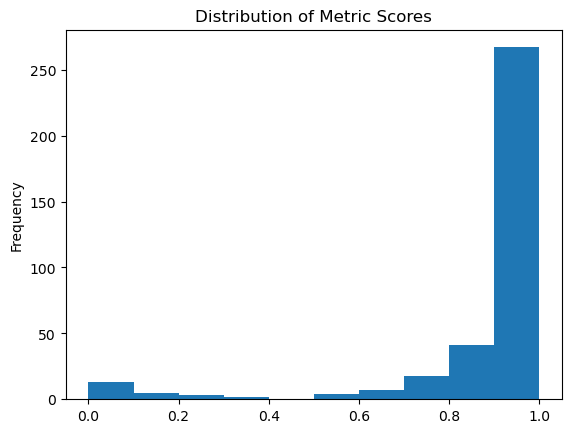

In [ ]:
df_results.metric_score.plot(kind='hist', bins=10, title='Distribution of Metric Scores')